# DATA 266 — CycleGAN: Monet ↔ Photo (unpaired image-to-image translation)

**Domain A = Monet paintings (300)**, **Domain B = real photos (7038)**. Two ResNet generators, two 70×70 PatchGAN discriminators, LSGAN adversarial loss + cycle-consistency + identity loss.

What's in here, in run order:

1. Personal parameters + seeding (Section 0.1 / 0.2)
2. Data discovery, loading, held-out split
3. Model (G: ResNet-9 blocks, D: PatchGAN), DiffAugment, image pool, EMA
4. Training with per-step logging of losses, gradient norms, NaN/Inf counts, D outputs; periodic FID for convergence tracking and best-checkpoint selection
5. Evaluation: FID / KID (both directions), precision/recall/density/coverage, cycle L1, LPIPS, content cosine, MiFID (Kaggle-style), efficiency
6. Cycle-consistency verification tests, error analysis
7. Kaggle submission (`images.zip`), blinded human audit packet + kappa scoring, `METRICS.md`

Everything that ends up in the repo (`RUN_LOG.txt`, `METRICS.md`, `figures/`, checkpoints) is written to `OUT_DIR`.

> Set `SID4` in the first code cell before running. Set `QUICK = True` for a 2-minute smoke test of the whole pipeline; set it back to `False` for the real run.

In [17]:
# ---- Personal parameters (Section 0.1) ------------------------------------
SID4  = 9002          # <-- TODO: last four digits of your SJSU ID
SEED  = SID4
SLICE = SID4 % 1000
HP_ID = SID4 % 6
CLS_A = SID4 % 10
CLS_B = (CLS_A + 1 + ((SID4 // 10) % 9)) % 10

print(f"SID4={SID4:04d}  SEED={SEED}  SLICE={SLICE}  HP_ID={HP_ID}  CLS_A={CLS_A}  CLS_B={CLS_B}")
# This homework only references SEED. SLICE / HP_ID / CLS_* are reported as required
# but not used (no HP_ID mapping or class subset is defined for this assignment).
assert SID4 != 0, "Set SID4 to the last four digits of your SJSU ID first."

SID4=9002  SEED=9002  SLICE=2  HP_ID=2  CLS_A=2  CLS_B=3


In [18]:
# Extra packages (torch / torchvision are assumed present)
%pip install -q torch-fidelity lpips

Note: you may need to restart the kernel to use updated packages.


In [19]:
import os, sys, io, json, math, time, random, copy, glob, zipfile, platform, datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy import linalg

import torch
import torch.nn as nn
import torch.nn.functional as F

# ---- Seeding (Section 0.2) -------------------------------------------------
def seed_everything(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
seed_everything(SEED)

# Speed over bit-exactness: cudnn autotuning picks kernels at runtime and some
# backward kernels (reflection-pad backward, conv-transpose wgrad) use atomics,
# so two runs with the same seed drift slightly. Discussed in the report.
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Output layout ----------------------------------------------------------
# ---- Locate the dataset ------------------------------------------------------
# Finds the folder that holds monet_jpg/ and photo_jpg/ automatically (works for
# /content on Colab, /app/content in Docker, ./content next to the notebook, ...).
# Only set DATA_ROOT by hand if auto-detection picks the wrong place.
DATA_ROOT = None
IMG_EXT = {".jpg", ".jpeg", ".png"}
SKIP_DIRS = {"proc", "sys", "dev", "node_modules", "site-packages", "dist-packages", "__pycache__",
             "data266_cyclegan", "checkpoints", "samples", "figures", "human_audit"}

def _walk(root, max_depth=6):
    root = Path(root)
    for dirpath, dirnames, filenames in os.walk(root):
        dirnames[:] = [d for d in dirnames if not d.startswith(".") and d not in SKIP_DIRS]
        if len(Path(dirpath).relative_to(root).parts) >= max_depth:
            dirnames[:] = []
        yield Path(dirpath), dirnames, filenames

def _n_imgs(d):
    try:
        return sum(1 for f in os.scandir(d) if f.is_file() and Path(f.name).suffix.lower() in IMG_EXT)
    except OSError:
        return 0

def _find_data(roots):
    for root in roots:
        for d, dirs, _ in _walk(root):
            low = {x.lower().strip(): x for x in dirs}
            if "monet_jpg" in low and "photo_jpg" in low:
                m, p = d / low["monet_jpg"], d / low["photo_jpg"]
                if _n_imgs(m) and _n_imgs(p):
                    return d, m, p
    return None

def _unzip_dataset(roots):
    for root in roots:
        for d, _, files in _walk(root, max_depth=3):
            for f in files:
                z = d / f
                if z.suffix.lower() != ".zip" or z.name == "images.zip" or z.with_suffix("").exists():
                    continue
                try:
                    with zipfile.ZipFile(z) as zf:
                        if any("monet_jpg" in n.lower() for n in zf.namelist()):
                            print(f"Extracting {z} ...")
                            zf.extractall(z.with_suffix(""))
                except zipfile.BadZipFile:
                    pass

_cands = [DATA_ROOT, os.getcwd(), os.path.join(os.getcwd(), "content"), "/app", "/content",
          "/workspace", "/kaggle/input", "/data", str(Path.home())]
SEARCH_ROOTS = list(dict.fromkeys(str(Path(r)) for r in _cands if r and os.path.isdir(r)))
_found = _find_data(SEARCH_ROOTS)
if _found is None:
    _unzip_dataset(SEARCH_ROOTS)
    _found = _find_data(SEARCH_ROOTS)
if _found is None:
    for r in SEARCH_ROOTS[:4]:
        print(f"{r!r}: {[repr(x) for x in sorted(os.listdir(r))][:30]}")
    raise FileNotFoundError("Couldn't find a folder containing monet_jpg/ and photo_jpg/. "
                            "Set DATA_ROOT above to that folder's full path and re-run.")
DATA_DIR, MONET_DIR, PHOTO_DIR = _found
print("Dataset folder:", repr(str(DATA_DIR)))

# ---- Output layout (next to the data so it survives a container restart) ----
OUT_DIR = DATA_DIR / "data266_cyclegan"
try:
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    (OUT_DIR / ".write_test").write_text("ok"); (OUT_DIR / ".write_test").unlink()
except OSError:
    OUT_DIR = Path(os.getcwd()) / "data266_cyclegan"
    print("Data folder is read-only; writing outputs to", OUT_DIR)
FIG_DIR  = OUT_DIR / "figures"
CKPT_DIR = OUT_DIR / "checkpoints"
SAMPLE_DIR = OUT_DIR / "samples"
for d in (OUT_DIR, FIG_DIR, CKPT_DIR, SAMPLE_DIR):
    d.mkdir(parents=True, exist_ok=True)
RUN_LOG = OUT_DIR / "RUN_LOG.txt"

def log(*args):
    msg = " ".join(str(a) for a in args)
    line = f"[{datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] {msg}"
    print(line, flush=True)
    with open(RUN_LOG, "a") as f:
        f.write(line + "\n")

log("=" * 70)
log(f"New session | SID4={SID4:04d} SEED={SEED} SLICE={SLICE} HP_ID={HP_ID} CLS_A={CLS_A} CLS_B={CLS_B}")
log(f"python {platform.python_version()} | torch {torch.__version__} | device {DEVICE}"
    + (f" | {torch.cuda.get_device_name(0)}" if DEVICE.type == "cuda" else ""))

Dataset folder: '/app/content'
[2026-10-01 01:22:24] ======================================================================
[2026-10-01 01:22:24] New session | SID4=9002 SEED=9002 SLICE=2 HP_ID=2 CLS_A=2 CLS_B=3
[2026-10-01 01:22:24] python 3.10.13 | torch 2.1.2 | device cuda | NVIDIA GeForce RTX 4090


## Configuration

Choices and why:

* **LSGAN** loss (least squares) — what the CycleGAN paper uses; noticeably more stable than BCE.
* **λ_cyc = 10, λ_id = 5** (= 0.5·λ_cyc, same as the reference implementation). The identity term keeps Monet's palette from drifting (the original paper uses it specifically for painting↔photo).
* **Batch 4, lr 2e-4, Adam(0.5, 0.999)**, constant LR for the first half then linear decay to 0.
* **DiffAugment (color + translation)** on everything the discriminators see. With only 300 Monet paintings the Monet discriminator memorises the training set quickly; differentiable augmentation is the most effective fix I know of for this (Zhao et al., 2020).
* **Image pool (50)** for the discriminator's fake inputs, as in the paper.
* **EMA of generator weights** — used for evaluation/submission; usually a few FID points better and less jittery than the raw weights.
* **bf16 autocast** — the 4090 supports it natively; no loss scaler needed (fp16 + GradScaler is a known source of NaNs in GANs).
* Images are preloaded to GPU memory as uint8 (~1.4 GB) and augmented on GPU, so there is no dataloader bottleneck.

In [20]:
QUICK = False    # True = tiny smoke test of the full pipeline

CFG = dict(
    data_root      = str(DATA_DIR),
    img_size       = 256,
    load_size      = 286,      # resize-then-random-crop jitter
    n_eval_photos  = 1000,     # held-out photos, never used for training

    ngf = 64, ndf = 64, n_res_blocks = 9,
    batch_size     = 4,
    lr             = 2e-4,
    betas          = (0.5, 0.999),
    lambda_cyc     = 10.0,
    lambda_id      = 5.0,
    pool_size      = 50,
    diffaug        = "color,translation",
    ema_decay      = 0.999,
    ema_start      = 1000,     # steps before EMA starts tracking

    epochs         = 50,
    epochs_decay   = 25,       # last N epochs: linear LR decay to 0
    steps_per_epoch= 800,
    grad_clip      = None,     # None = only measure the norm, don't clip

    log_every      = 100,
    sample_every   = 5,        # epochs
    eval_every     = 5,        # epochs (FID on held-out set, both directions)
    ckpt_every     = 5,
    resume         = True,
    use_bf16       = DEVICE.type == "cuda",
    channels_last  = DEVICE.type == "cuda",
)
if QUICK:
    CFG.update(epochs=2, epochs_decay=1, steps_per_epoch=20, n_eval_photos=64,
               log_every=5, sample_every=1, eval_every=1, ckpt_every=1, ema_start=5)

with open(OUT_DIR / "config.json", "w") as f:
    json.dump({**CFG, "SID4": SID4, "SEED": SEED, "QUICK": QUICK}, f, indent=2)
log("CFG:", json.dumps(CFG))

[2026-10-01 01:22:26] CFG: {"data_root": "/app/content", "img_size": 256, "load_size": 286, "n_eval_photos": 1000, "ngf": 64, "ndf": 64, "n_res_blocks": 9, "batch_size": 4, "lr": 0.0002, "betas": [0.5, 0.999], "lambda_cyc": 10.0, "lambda_id": 5.0, "pool_size": 50, "diffaug": "color,translation", "ema_decay": 0.999, "ema_start": 1000, "epochs": 50, "epochs_decay": 25, "steps_per_epoch": 800, "grad_clip": null, "log_every": 100, "sample_every": 5, "eval_every": 5, "ckpt_every": 5, "resume": true, "use_bf16": true, "channels_last": true}


## 1. Data

In [21]:
def list_imgs(d):
    return sorted(p for p in Path(d).iterdir() if p.is_file() and p.suffix.lower() in IMG_EXT)

monet_files = list_imgs(MONET_DIR)
photo_files = list_imgs(PHOTO_DIR)
log(f"Monet dir: {MONET_DIR} ({len(monet_files)} files)")
log(f"Photo dir: {PHOTO_DIR} ({len(photo_files)} files)")
if not QUICK and (len(monet_files) != 300 or len(photo_files) != 7038):
    log("WARNING: expected 300 Monet / 7038 photos - check the dataset copy is complete.")

# The Data tab lists .npz files too — print whatever is there so we know what it is
for p in glob.glob(os.path.join(CFG["data_root"], "**", "*.npz"), recursive=True):
    try:
        with np.load(p) as z:
            log(f"npz found: {p} -> " + ", ".join(f"{k}{z[k].shape}" for k in z.files))
    except Exception as e:
        log(f"npz found: {p} (could not open: {e})")

[2026-10-01 01:22:38] Monet dir: /app/content/monet_jpg (300 files)
[2026-10-01 01:22:38] Photo dir: /app/content/photo_jpg (7038 files)


In [22]:
def load_uint8(files, size):
    out = np.empty((len(files), size, size, 3), dtype=np.uint8)
    for i, f in enumerate(files):
        im = Image.open(f).convert("RGB")
        if im.size != (size, size):
            im = im.resize((size, size), Image.BICUBIC)
        out[i] = np.asarray(im)
    return torch.from_numpy(out).permute(0, 3, 1, 2).contiguous()   # N,3,H,W uint8

t0 = time.time()
monet_u8 = load_uint8(monet_files, CFG["img_size"])
photo_u8 = load_uint8(photo_files, CFG["img_size"])
log(f"Loaded images in {time.time()-t0:.1f}s | monet {tuple(monet_u8.shape)} photo {tuple(photo_u8.shape)}")

# Held-out photo split (seeded). All 300 Monet paintings are used for training —
# there are too few to hold any out, so Monet-side FID is measured against the
# training paintings (caveat noted in the analysis).
rng = np.random.RandomState(SEED)
perm = rng.permutation(len(photo_files))
eval_idx  = np.sort(perm[:CFG["n_eval_photos"]])
train_idx = np.sort(perm[CFG["n_eval_photos"]:])
if QUICK:
    train_idx = train_idx[:256]
log(f"Photo split: train {len(train_idx)} / held-out eval {len(eval_idx)}")

monet_train = monet_u8.to(DEVICE)
photo_train = photo_u8[train_idx].to(DEVICE)
photo_eval  = photo_u8[eval_idx]          # stays on CPU, moved per batch

[2026-10-01 01:23:00] Loaded images in 19.7s | monet (300, 3, 256, 256) photo (7038, 3, 256, 256)
[2026-10-01 01:23:00] Photo split: train 6038 / held-out eval 1000


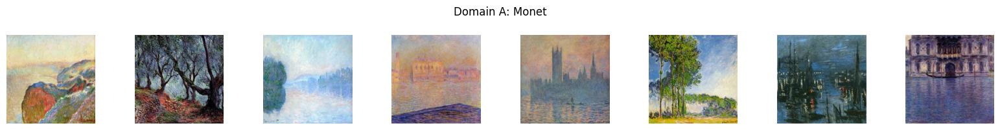

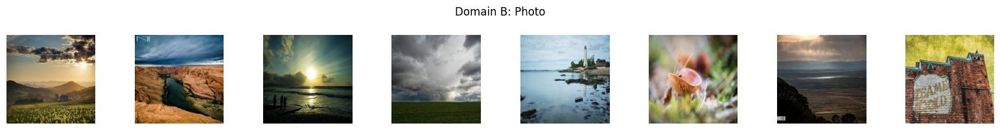

In [23]:
def show_grid(imgs_u8, ncol=8, title=None, path=None):
    n = len(imgs_u8); nrow = math.ceil(n / ncol)
    fig, axes = plt.subplots(nrow, ncol, figsize=(2 * ncol, 2 * nrow))
    for ax in np.array(axes).ravel(): ax.axis("off")
    for ax, im in zip(np.array(axes).ravel(), imgs_u8):
        ax.imshow(im.permute(1, 2, 0).cpu().numpy())
    if title: fig.suptitle(title)
    plt.tight_layout()
    if path: fig.savefig(path, dpi=110, bbox_inches="tight")
    plt.show()

show_grid(monet_u8[:8], title="Domain A: Monet", path=FIG_DIR / "data_monet.png")
show_grid(photo_u8[:8], title="Domain B: Photo", path=FIG_DIR / "data_photo.png")

In [24]:
def to_float(x_u8):
    return x_u8.float().div_(127.5).sub_(1.0)

def to_u8(x):
    return ((x.float().clamp(-1, 1) + 1) * 127.5).round().to(torch.uint8)

def sample_batch(pool_u8, bs, train=True):
    idx = torch.randint(0, len(pool_u8), (bs,), device=pool_u8.device)
    x = to_float(pool_u8[idx])
    if not train:
        return x
    # random horizontal flip
    flip = torch.rand(bs, device=x.device) < 0.5
    x = torch.where(flip[:, None, None, None], x.flip(3), x)
    # resize to load_size, random crop back to img_size (per-sample offsets)
    L, S = CFG["load_size"], CFG["img_size"]
    x = F.interpolate(x, size=(L, L), mode="bilinear", align_corners=False)
    oy = torch.randint(0, L - S + 1, (bs,)); ox = torch.randint(0, L - S + 1, (bs,))
    x = torch.stack([x[i, :, oy[i]:oy[i]+S, ox[i]:ox[i]+S] for i in range(bs)])
    return x.contiguous(memory_format=torch.channels_last) if CFG["channels_last"] else x

## 2. Model

Generator: c7s1-64, d128, d256, 9× residual blocks (256), u128, u64, c7s1-3 + tanh — the architecture from Zhu et al. (2017) for 256×256 inputs, with reflection padding and InstanceNorm.
Discriminator: 70×70 PatchGAN (C64-C128-C256-C512, no norm on the first layer), outputs a 30×30 map of real/fake scores.

In [25]:
class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1), nn.Conv2d(ch, ch, 3), nn.InstanceNorm2d(ch), nn.ReLU(True),
            nn.ReflectionPad2d(1), nn.Conv2d(ch, ch, 3), nn.InstanceNorm2d(ch))
    def forward(self, x):
        return x + self.block(x)

class ResnetGenerator(nn.Module):
    def __init__(self, ngf=64, n_blocks=9):
        super().__init__()
        layers = [nn.ReflectionPad2d(3), nn.Conv2d(3, ngf, 7), nn.InstanceNorm2d(ngf), nn.ReLU(True)]
        ch = ngf
        for _ in range(2):                                    # downsample
            layers += [nn.Conv2d(ch, ch * 2, 3, 2, 1), nn.InstanceNorm2d(ch * 2), nn.ReLU(True)]
            ch *= 2
        layers += [ResBlock(ch) for _ in range(n_blocks)]
        for _ in range(2):                                    # upsample
            layers += [nn.ConvTranspose2d(ch, ch // 2, 3, 2, 1, output_padding=1),
                       nn.InstanceNorm2d(ch // 2), nn.ReLU(True)]
            ch //= 2
        layers += [nn.ReflectionPad2d(3), nn.Conv2d(ch, 3, 7), nn.Tanh()]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

class PatchDiscriminator(nn.Module):
    def __init__(self, ndf=64):
        super().__init__()
        def blk(i, o, s, norm=True):
            l = [nn.Conv2d(i, o, 4, s, 1)]
            if norm: l.append(nn.InstanceNorm2d(o))
            l.append(nn.LeakyReLU(0.2, True))
            return l
        self.net = nn.Sequential(
            *blk(3, ndf, 2, norm=False), *blk(ndf, ndf * 2, 2), *blk(ndf * 2, ndf * 4, 2),
            *blk(ndf * 4, ndf * 8, 1), nn.Conv2d(ndf * 8, 1, 4, 1, 1))
    def forward(self, x):
        return self.net(x)

def init_weights(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight, 0.0, 0.02)
        if m.bias is not None: nn.init.zeros_(m.bias)

In [26]:
# DiffAugment (Zhao et al., 2020) — differentiable, applied identically in spirit to
# real and fake images going into D, so G still receives gradients through it.
def _brightness(x): return x + (torch.rand(x.size(0), 1, 1, 1, device=x.device) - 0.5)
def _saturation(x):
    m = x.mean(dim=1, keepdim=True)
    return (x - m) * (torch.rand(x.size(0), 1, 1, 1, device=x.device) * 2) + m
def _contrast(x):
    m = x.mean(dim=[1, 2, 3], keepdim=True)
    return (x - m) * (torch.rand(x.size(0), 1, 1, 1, device=x.device) + 0.5) + m
def _translation(x, ratio=0.125):
    B, _, H, W = x.shape
    sx, sy = int(H * ratio + 0.5), int(W * ratio + 0.5)
    tx = torch.randint(-sx, sx + 1, (B, 1, 1), device=x.device)
    ty = torch.randint(-sy, sy + 1, (B, 1, 1), device=x.device)
    gb, gx, gy = torch.meshgrid(torch.arange(B, device=x.device), torch.arange(H, device=x.device),
                                torch.arange(W, device=x.device), indexing="ij")
    gx = torch.clamp(gx + tx + 1, 0, H + 1); gy = torch.clamp(gy + ty + 1, 0, W + 1)
    xp = F.pad(x, [1, 1, 1, 1])
    return xp.permute(0, 2, 3, 1)[gb, gx, gy].permute(0, 3, 1, 2).contiguous()
def _cutout(x, ratio=0.5):
    B, _, H, W = x.shape
    ch, cw = int(H * ratio + 0.5), int(W * ratio + 0.5)
    ox = torch.randint(0, H + (1 - ch % 2), (B, 1, 1), device=x.device)
    oy = torch.randint(0, W + (1 - cw % 2), (B, 1, 1), device=x.device)
    gb, gx, gy = torch.meshgrid(torch.arange(B, device=x.device), torch.arange(ch, device=x.device),
                                torch.arange(cw, device=x.device), indexing="ij")
    gx = torch.clamp(gx + ox - ch // 2, 0, H - 1); gy = torch.clamp(gy + oy - cw // 2, 0, W - 1)
    mask = torch.ones(B, H, W, dtype=x.dtype, device=x.device)
    mask[gb, gx, gy] = 0
    return x * mask.unsqueeze(1)

_AUG = {"color": [_brightness, _saturation, _contrast], "translation": [_translation], "cutout": [_cutout]}
def diff_augment(x, policy=CFG["diffaug"]):
    if not policy: return x
    for p in policy.split(","):
        for fn in _AUG[p]:
            x = fn(x)
    return x

class ImagePool:
    # History buffer of generated images (Shrivastava et al., 2017)
    def __init__(self, size): self.size, self.items = size, []
    def query(self, imgs):
        if self.size == 0: return imgs
        out = []
        for im in imgs.detach():
            im = im.unsqueeze(0)
            if len(self.items) < self.size:
                self.items.append(im); out.append(im)
            elif random.random() < 0.5:
                j = random.randrange(self.size)
                out.append(self.items[j].clone()); self.items[j] = im
            else:
                out.append(im)
        return torch.cat(out)

@torch.no_grad()
def ema_update(ema, model, decay):
    for pe, pm in zip(ema.parameters(), model.parameters()):
        pe.lerp_(pm.detach(), 1 - decay)

In [27]:
seed_everything(SEED)
G_P2M = ResnetGenerator(CFG["ngf"], CFG["n_res_blocks"])   # photo -> Monet
G_M2P = ResnetGenerator(CFG["ngf"], CFG["n_res_blocks"])   # Monet -> photo
D_M   = PatchDiscriminator(CFG["ndf"])                      # real vs fake Monet
D_P   = PatchDiscriminator(CFG["ndf"])                      # real vs fake photo
for m in (G_P2M, G_M2P, D_M, D_P):
    m.apply(init_weights)
    m.to(DEVICE)
    if CFG["channels_last"]: m.to(memory_format=torch.channels_last)

EMA_P2M = copy.deepcopy(G_P2M).eval().requires_grad_(False)
EMA_M2P = copy.deepcopy(G_M2P).eval().requires_grad_(False)

n_params = lambda m: sum(p.numel() for p in m.parameters())
PARAMS = {"G_P2M": n_params(G_P2M), "G_M2P": n_params(G_M2P), "D_M": n_params(D_M), "D_P": n_params(D_P)}
PARAMS["total"] = sum(PARAMS.values())
log("Parameter counts:", {k: f"{v/1e6:.3f}M" for k, v in PARAMS.items()})

opt_G = torch.optim.Adam(list(G_P2M.parameters()) + list(G_M2P.parameters()), lr=CFG["lr"], betas=CFG["betas"])
opt_D = torch.optim.Adam(list(D_M.parameters()) + list(D_P.parameters()), lr=CFG["lr"], betas=CFG["betas"])

TOTAL_STEPS = CFG["epochs"] * CFG["steps_per_epoch"]
DECAY_START = (CFG["epochs"] - CFG["epochs_decay"]) * CFG["steps_per_epoch"]
def lr_factor(step):
    if step < DECAY_START: return 1.0
    return max(0.0, 1.0 - (step - DECAY_START) / float(TOTAL_STEPS - DECAY_START + 1))
sched_G = torch.optim.lr_scheduler.LambdaLR(opt_G, lr_factor)
sched_D = torch.optim.lr_scheduler.LambdaLR(opt_D, lr_factor)

pool_M, pool_P = ImagePool(CFG["pool_size"]), ImagePool(CFG["pool_size"])
mse, l1 = nn.MSELoss(), nn.L1Loss()
AMP = dict(device_type="cuda", dtype=torch.bfloat16, enabled=CFG["use_bf16"])

[2026-10-01 01:23:50] Parameter counts: {'G_P2M': '11.378M', 'G_M2P': '11.378M', 'D_M': '2.765M', 'D_P': '2.765M', 'total': '28.286M'}


## 3. Evaluation utilities

All distribution metrics use 2048-d pool features from the standard FID Inception-v3 (`inception-v3-compat` from torch-fidelity, i.e. the same network as the TF reference implementation and Kaggle's MiFID scorer), so numbers are comparable with published values. Features are extracted once per image set and reused for FID, KID, PRDC, MiFID and the content cosine.

In [28]:
from torch_fidelity.feature_extractor_inceptionv3 import FeatureExtractorInceptionV3
INCEPTION = FeatureExtractorInceptionV3("inception-v3-compat", ["2048"]).to(DEVICE).eval()

@torch.no_grad()
def inception_feats(imgs_u8, bs=100):
    out = []
    for i in range(0, len(imgs_u8), bs):
        out.append(INCEPTION(imgs_u8[i:i+bs].to(DEVICE))[0].double().cpu())
    return torch.cat(out).numpy()

@torch.no_grad()
def translate(G, imgs_u8, bs=32):
    G.eval(); out = []
    for i in range(0, len(imgs_u8), bs):
        x = to_float(imgs_u8[i:i+bs].to(DEVICE))
        if CFG["channels_last"]: x = x.contiguous(memory_format=torch.channels_last)
        with torch.autocast(**AMP):
            y = G(x)
        out.append(to_u8(y).cpu())
    return torch.cat(out)

def fid_from_feats(f1, f2):
    mu1, mu2 = f1.mean(0), f2.mean(0)
    s1, s2 = np.cov(f1, rowvar=False), np.cov(f2, rowvar=False)
    covmean, _ = linalg.sqrtm(s1 @ s2, disp=False)
    if not np.isfinite(covmean).all():
        off = np.eye(s1.shape[0]) * 1e-6
        covmean = linalg.sqrtm((s1 + off) @ (s2 + off))
    covmean = covmean.real
    return float(((mu1 - mu2) ** 2).sum() + np.trace(s1) + np.trace(s2) - 2 * np.trace(covmean))

def kid_from_feats(f1, f2, n_subsets=100, subset_size=None, seed=SEED):
    # Unbiased MMD^2 with cubic polynomial kernel (Binkowski et al., 2018)
    rs = np.random.RandomState(seed)
    m = subset_size or min(len(f1), len(f2), 1000)
    d = f1.shape[1]; vals = []
    for _ in range(n_subsets):
        x = f1[rs.choice(len(f1), m, replace=False)]
        y = f2[rs.choice(len(f2), m, replace=False)]
        kxx = (x @ x.T / d + 1) ** 3; kyy = (y @ y.T / d + 1) ** 3; kxy = (x @ y.T / d + 1) ** 3
        vals.append((kxx.sum() - np.trace(kxx)) / (m * (m - 1))
                    + (kyy.sum() - np.trace(kyy)) / (m * (m - 1)) - 2 * kxy.mean())
    return float(np.mean(vals)), float(np.std(vals))

def prdc_from_feats(real, fake, k=5):
    # Precision / recall (Kynkaanniemi 2019) and density / coverage (Naeem 2020)
    real = torch.from_numpy(real).float().to(DEVICE); fake = torch.from_numpy(fake).float().to(DEVICE)
    d_rr = torch.cdist(real, real); d_ff = torch.cdist(fake, fake); d_rf = torch.cdist(real, fake)
    r_rad = d_rr.kthvalue(k + 1, dim=1).values         # +1 skips self-distance
    f_rad = d_ff.kthvalue(k + 1, dim=1).values
    precision = (d_rf < r_rad[:, None]).any(0).float().mean().item()
    recall    = (d_rf < f_rad[None, :]).any(1).float().mean().item()
    density   = ((d_rf < r_rad[:, None]).float().sum(0) / k).mean().item()
    coverage  = (d_rf.min(1).values < r_rad).float().mean().item()
    return dict(precision=precision, recall=recall, density=density, coverage=coverage)

def mifid_from_feats(gen, train, fid, eps=0.1):
    # Kaggle "I'm Something of a Painter" memorisation-informed FID
    g = gen / np.linalg.norm(gen, axis=1, keepdims=True)
    t = train / np.linalg.norm(train, axis=1, keepdims=True)
    d = float((1 - g @ t.T).min(1).mean())
    d_thr = d if d < eps else 1.0
    return fid / (d_thr + 1e-15), d

REAL_MONET_FEATS = inception_feats(monet_u8)
REAL_PHOTO_EVAL_FEATS = inception_feats(photo_eval)
log(f"Reference features: Monet {REAL_MONET_FEATS.shape}, held-out photo {REAL_PHOTO_EVAL_FEATS.shape}")

def quick_eval(gp2m, gm2p):
    fm = inception_feats(translate(gp2m, photo_eval))
    fp = inception_feats(translate(gm2p, monet_u8))
    return fid_from_feats(fm, REAL_MONET_FEATS), fid_from_feats(fp, REAL_PHOTO_EVAL_FEATS)

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:06<00:00, 14.9MB/s]


[2026-10-01 01:24:04] Reference features: Monet (300, 2048), held-out photo (1000, 2048)


## 4. Training

Per step: generator update (adversarial + λ_cyc·cycle + λ_id·identity, both directions), then discriminator update on real vs. pooled fakes. Every step logs every loss term, the global gradient norm of G and D, the mean D score on real/fake, and whether anything went non-finite (a non-finite step is skipped and counted, not applied).

The loop checkpoints every few epochs and resumes from `last.pt` automatically, so a disconnect doesn't cost the whole run.

In [29]:
HIST = []          # one dict per logged step
EVAL_HIST = []     # periodic FID
STATE = dict(step=0, epoch=0, nan_steps=0, best_fid=float("inf"), train_time=0.0)

def save_ckpt(path):
    torch.save(dict(G_P2M=G_P2M.state_dict(), G_M2P=G_M2P.state_dict(), D_M=D_M.state_dict(), D_P=D_P.state_dict(),
                    EMA_P2M=EMA_P2M.state_dict(), EMA_M2P=EMA_M2P.state_dict(),
                    opt_G=opt_G.state_dict(), opt_D=opt_D.state_dict(),
                    sched_G=sched_G.state_dict(), sched_D=sched_D.state_dict(),
                    HIST=HIST, EVAL_HIST=EVAL_HIST, STATE=STATE, CFG=CFG), path)

last_ckpt = CKPT_DIR / "last.pt"
if CFG["resume"] and last_ckpt.exists():
    ck = torch.load(last_ckpt, map_location=DEVICE, weights_only=False)
    for name, obj in [("G_P2M", G_P2M), ("G_M2P", G_M2P), ("D_M", D_M), ("D_P", D_P),
                      ("EMA_P2M", EMA_P2M), ("EMA_M2P", EMA_M2P), ("opt_G", opt_G), ("opt_D", opt_D),
                      ("sched_G", sched_G), ("sched_D", sched_D)]:
        obj.load_state_dict(ck[name])
    HIST, EVAL_HIST, STATE = ck["HIST"], ck["EVAL_HIST"], ck["STATE"]
    log(f"Resumed from {last_ckpt} at epoch {STATE['epoch']} step {STATE['step']}")

In [30]:
def grad_norm(params):
    params = [p for p in params if p.grad is not None]
    if CFG["grad_clip"]:
        return torch.nn.utils.clip_grad_norm_(params, CFG["grad_clip"]).item()
    return torch.norm(torch.stack([p.grad.detach().float().norm() for p in params])).item()

def set_requires_grad(nets, flag):
    for n in nets:
        for p in n.parameters(): p.requires_grad_(flag)

G_params = list(G_P2M.parameters()) + list(G_M2P.parameters())
D_params = list(D_M.parameters()) + list(D_P.parameters())

# fixed visualisation inputs
vis_photo = to_float(photo_eval[:4].to(DEVICE)); vis_monet = to_float(monet_u8[:4].to(DEVICE))

@torch.no_grad()
def save_samples(epoch):
    fm = EMA_P2M(vis_photo); rp = EMA_M2P(fm)
    fp = EMA_M2P(vis_monet); rm = EMA_P2M(fp)
    rows = torch.cat([vis_photo, fm, rp, vis_monet, fp, rm])
    grid = to_u8(rows).cpu()
    fig, axes = plt.subplots(6, 4, figsize=(8, 12))
    labels = ["photo", "→Monet", "→photo (rec)", "Monet", "→photo", "→Monet (rec)"]
    for i, ax in enumerate(axes.ravel()):
        ax.imshow(grid[i].permute(1, 2, 0).numpy()); ax.set_xticks([]); ax.set_yticks([])
        if i % 4 == 0: ax.set_ylabel(labels[i // 4])
    fig.suptitle(f"epoch {epoch} (EMA generators)")
    plt.tight_layout(); fig.savefig(SAMPLE_DIR / f"epoch_{epoch:03d}.png", dpi=80); plt.close(fig)

if DEVICE.type == "cuda":
    torch.cuda.reset_peak_memory_stats()

log(f"Training: {CFG['epochs']} epochs x {CFG['steps_per_epoch']} steps = {TOTAL_STEPS} steps, batch {CFG['batch_size']}")
bs = CFG["batch_size"]

for epoch in range(STATE["epoch"] + 1, CFG["epochs"] + 1):
    G_P2M.train(); G_M2P.train(); D_M.train(); D_P.train()
    if DEVICE.type == "cuda": torch.cuda.synchronize()
    t_epoch = time.time(); acc = {}

    for it in range(CFG["steps_per_epoch"]):
        real_P = sample_batch(photo_train, bs)
        real_M = sample_batch(monet_train, bs)

        # ---------------- Generators ----------------
        set_requires_grad([D_M, D_P], False)
        with torch.autocast(**AMP):
            fake_M = G_P2M(real_P); rec_P = G_M2P(fake_M)
            fake_P = G_M2P(real_M); rec_M = G_P2M(fake_P)
            idt_M  = G_P2M(real_M); idt_P = G_M2P(real_P)
            pred_fM = D_M(diff_augment(fake_M)); pred_fP = D_P(diff_augment(fake_P))
            loss_adv_P2M = mse(pred_fM.float(), torch.ones_like(pred_fM, dtype=torch.float32))
            loss_adv_M2P = mse(pred_fP.float(), torch.ones_like(pred_fP, dtype=torch.float32))
            loss_cyc_P = l1(rec_P.float(), real_P); loss_cyc_M = l1(rec_M.float(), real_M)
            loss_idt_M = l1(idt_M.float(), real_M); loss_idt_P = l1(idt_P.float(), real_P)
            loss_G = (loss_adv_P2M + loss_adv_M2P
                      + CFG["lambda_cyc"] * (loss_cyc_P + loss_cyc_M)
                      + CFG["lambda_id"]  * (loss_idt_M + loss_idt_P))
        opt_G.zero_grad(set_to_none=True)
        loss_G.backward()
        gn_G = grad_norm(G_params)
        ok_G = math.isfinite(loss_G.item()) and math.isfinite(gn_G)
        if ok_G: opt_G.step()

        # ---------------- Discriminators ----------------
        set_requires_grad([D_M, D_P], True)
        fM_pool = pool_M.query(fake_M.detach()); fP_pool = pool_P.query(fake_P.detach())
        with torch.autocast(**AMP):
            pr_M = D_M(diff_augment(real_M)).float(); pf_M = D_M(diff_augment(fM_pool)).float()
            pr_P = D_P(diff_augment(real_P)).float(); pf_P = D_P(diff_augment(fP_pool)).float()
            loss_D_M = 0.5 * (mse(pr_M, torch.ones_like(pr_M)) + mse(pf_M, torch.zeros_like(pf_M)))
            loss_D_P = 0.5 * (mse(pr_P, torch.ones_like(pr_P)) + mse(pf_P, torch.zeros_like(pf_P)))
            loss_D = loss_D_M + loss_D_P
        opt_D.zero_grad(set_to_none=True)
        loss_D.backward()
        gn_D = grad_norm(D_params)
        ok_D = math.isfinite(loss_D.item()) and math.isfinite(gn_D)
        if ok_D: opt_D.step()

        if not (ok_G and ok_D):
            STATE["nan_steps"] += 1
            log(f"non-finite step {STATE['step']}: loss_G={loss_G.item()} gn_G={gn_G} loss_D={loss_D.item()} gn_D={gn_D}")

        sched_G.step(); sched_D.step()
        STATE["step"] += 1
        if STATE["step"] >= CFG["ema_start"]:
            ema_update(EMA_P2M, G_P2M, CFG["ema_decay"]); ema_update(EMA_M2P, G_M2P, CFG["ema_decay"])
        else:
            EMA_P2M.load_state_dict(G_P2M.state_dict()); EMA_M2P.load_state_dict(G_M2P.state_dict())

        rec = dict(step=STATE["step"], epoch=epoch, lr=opt_G.param_groups[0]["lr"],
                   G=loss_G.item(), D=loss_D.item(), D_M=loss_D_M.item(), D_P=loss_D_P.item(),
                   adv_P2M=loss_adv_P2M.item(), adv_M2P=loss_adv_M2P.item(),
                   cyc_P=loss_cyc_P.item(), cyc_M=loss_cyc_M.item(),
                   idt_M=loss_idt_M.item(), idt_P=loss_idt_P.item(),
                   gn_G=gn_G, gn_D=gn_D,
                   Dreal_M=pr_M.mean().item(), Dfake_M=pf_M.mean().item(),
                   Dreal_P=pr_P.mean().item(), Dfake_P=pf_P.mean().item())
        HIST.append(rec)
        for k, v in rec.items(): acc[k] = acc.get(k, 0.0) + v

        if STATE["step"] % CFG["log_every"] == 0:
            log(f"ep {epoch:3d} step {STATE['step']:6d} | G {rec['G']:.3f} D {rec['D']:.3f} | "
                f"adv {rec['adv_P2M']:.3f}/{rec['adv_M2P']:.3f} cyc {rec['cyc_P']:.3f}/{rec['cyc_M']:.3f} "
                f"idt {rec['idt_M']:.3f}/{rec['idt_P']:.3f} | gn G {gn_G:.2f} D {gn_D:.2f} | lr {rec['lr']:.2e}")

    if DEVICE.type == "cuda": torch.cuda.synchronize()
    dt = time.time() - t_epoch
    STATE["train_time"] += dt; STATE["epoch"] = epoch
    n = CFG["steps_per_epoch"]
    log(f"== epoch {epoch} done in {dt:.1f}s ({n*bs/dt:.1f} img/s per domain) | "
        f"mean G {acc['G']/n:.3f} D {acc['D']/n:.3f} cyc {(acc['cyc_P']+acc['cyc_M'])/n:.3f} | NaN steps {STATE['nan_steps']}")
    if epoch == 1 or epoch % 10 == 0:
        log(f"   ETA for remaining epochs: {(CFG['epochs']-epoch)*dt/60:.1f} min")

    if epoch % CFG["sample_every"] == 0 or epoch == CFG["epochs"]:
        save_samples(epoch)

    if epoch % CFG["eval_every"] == 0 or epoch == CFG["epochs"]:
        fid_p2m, fid_m2p = quick_eval(EMA_P2M, EMA_M2P)
        EVAL_HIST.append(dict(epoch=epoch, step=STATE["step"], fid_p2m=fid_p2m, fid_m2p=fid_m2p))
        log(f"   eval @ epoch {epoch}: FID photo->Monet {fid_p2m:.2f} | FID Monet->photo {fid_m2p:.2f}")
        if fid_p2m < STATE["best_fid"]:
            STATE["best_fid"] = fid_p2m
            torch.save(dict(EMA_P2M=EMA_P2M.state_dict(), EMA_M2P=EMA_M2P.state_dict(), epoch=epoch,
                            fid_p2m=fid_p2m, fid_m2p=fid_m2p), CKPT_DIR / "best_ema.pt")
            log(f"   new best (photo->Monet FID {fid_p2m:.2f}) saved to best_ema.pt")

    if epoch % CFG["ckpt_every"] == 0 or epoch == CFG["epochs"]:
        save_ckpt(last_ckpt)

PEAK_TRAIN_MEM_GB = torch.cuda.max_memory_allocated() / 1024**3 if DEVICE.type == "cuda" else float("nan")
log(f"Training finished. total train time {STATE['train_time']/3600:.2f} h | NaN/Inf steps {STATE['nan_steps']} | "
    f"peak GPU mem {PEAK_TRAIN_MEM_GB:.2f} GB")

[2026-10-01 01:25:15] Training: 50 epochs x 800 steps = 40000 steps, batch 4
[2026-10-01 01:25:33] ep   1 step    100 | G 8.110 D 0.679 | adv 0.329/0.363 cyc 0.250/0.261 idt 0.240/0.222 | gn G 35.37 D 16.14 | lr 2.00e-04
[2026-10-01 01:25:50] ep   1 step    200 | G 10.615 D 0.543 | adv 0.347/0.295 cyc 0.370/0.348 idt 0.247/0.311 | gn G 66.93 D 14.25 | lr 2.00e-04
[2026-10-01 01:26:08] ep   1 step    300 | G 8.025 D 0.459 | adv 0.328/0.326 cyc 0.274/0.239 idt 0.202/0.245 | gn G 77.91 D 14.16 | lr 2.00e-04
[2026-10-01 01:26:25] ep   1 step    400 | G 9.080 D 0.686 | adv 0.548/0.343 cyc 0.342/0.226 idt 0.185/0.317 | gn G 40.72 D 36.70 | lr 2.00e-04
[2026-10-01 01:26:42] ep   1 step    500 | G 7.416 D 0.496 | adv 0.354/0.350 cyc 0.215/0.258 idt 0.193/0.203 | gn G 45.24 D 13.90 | lr 2.00e-04
[2026-10-01 01:26:59] ep   1 step    600 | G 6.738 D 0.466 | adv 0.297/0.367 cyc 0.199/0.222 idt 0.198/0.176 | gn G 31.02 D 12.27 | lr 2.00e-04
[2026-10-01 01:27:16] ep   1 step    700 | G 5.582 D 0.509

## 5. Training behaviour: losses, gradient norms, convergence

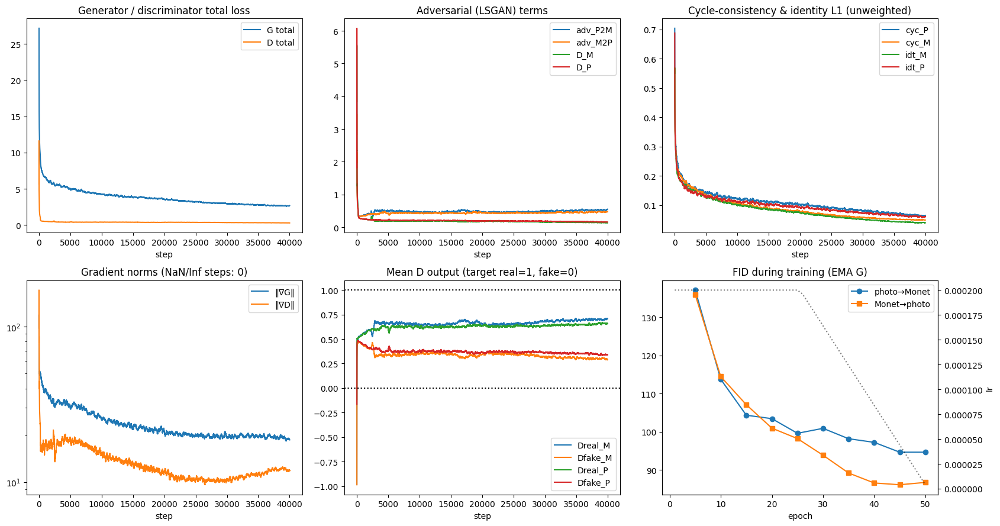

[2026-10-01 03:17:36] Stability summary: {"nan_inf_steps": 0.0, "gnG_median": 21.7251, "gnG_p99": 53.1556, "gnG_max": 198.2946, "gnD_median": 11.7988, "gnD_p99": 31.39, "gnD_max": 245.8762, "cyc_first_quarter": 0.299, "cyc_last_quarter": 0.1255, "idt_last_quarter": 0.1114, "D_last_quarter": 0.3262, "G_adv_last_quarter": 0.9729, "G_std_last_quarter": 0.3256, "D_std_last_quarter": 0.0633}


nan_inf_steps           0.0000
gnG_median             21.7251
gnG_p99                53.1556
gnG_max               198.2946
gnD_median             11.7988
gnD_p99                31.3900
gnD_max               245.8762
cyc_first_quarter       0.2990
cyc_last_quarter        0.1255
idt_last_quarter        0.1114
D_last_quarter          0.3262
G_adv_last_quarter      0.9729
G_std_last_quarter      0.3256
D_std_last_quarter      0.0633
dtype: float64

In [31]:
H = pd.DataFrame(HIST)
E = pd.DataFrame(EVAL_HIST)
H.to_csv(OUT_DIR / "train_history.csv", index=False); E.to_csv(OUT_DIR / "eval_history.csv", index=False)
win = max(1, CFG["steps_per_epoch"] // 4)
sm = lambda s: s.rolling(win, min_periods=1).mean()

fig, ax = plt.subplots(2, 3, figsize=(17, 9))
ax[0,0].plot(H.step, sm(H.G), label="G total"); ax[0,0].plot(H.step, sm(H.D), label="D total")
ax[0,0].set_title("Generator / discriminator total loss"); ax[0,0].legend()
for c in ["adv_P2M", "adv_M2P", "D_M", "D_P"]: ax[0,1].plot(H.step, sm(H[c]), label=c)
ax[0,1].set_title("Adversarial (LSGAN) terms"); ax[0,1].legend()
for c in ["cyc_P", "cyc_M", "idt_M", "idt_P"]: ax[0,2].plot(H.step, sm(H[c]), label=c)
ax[0,2].set_title("Cycle-consistency & identity L1 (unweighted)"); ax[0,2].legend()
ax[1,0].plot(H.step, sm(H.gn_G), label="‖∇G‖"); ax[1,0].plot(H.step, sm(H.gn_D), label="‖∇D‖")
ax[1,0].set_yscale("log"); ax[1,0].set_title(f"Gradient norms (NaN/Inf steps: {STATE['nan_steps']})"); ax[1,0].legend()
for c in ["Dreal_M", "Dfake_M", "Dreal_P", "Dfake_P"]: ax[1,1].plot(H.step, sm(H[c]), label=c)
ax[1,1].axhline(1, ls=":", c="k"); ax[1,1].axhline(0, ls=":", c="k")
ax[1,1].set_title("Mean D output (target real=1, fake=0)"); ax[1,1].legend()
if len(E):
    ax[1,2].plot(E.epoch, E.fid_p2m, "o-", label="photo→Monet"); ax[1,2].plot(E.epoch, E.fid_m2p, "s-", label="Monet→photo")
    ax2 = ax[1,2].twinx(); ax2.plot(H.epoch.unique(), H.groupby("epoch").lr.mean(), "k:", alpha=.5); ax2.set_ylabel("lr")
ax[1,2].set_title("FID during training (EMA G)"); ax[1,2].set_xlabel("epoch"); ax[1,2].legend()
for a in ax.ravel()[:5]: a.set_xlabel("step")
plt.tight_layout(); fig.savefig(FIG_DIR / "training_curves.png", dpi=120); plt.show()

# Simple stability numbers for the report
q = len(H) // 4
stab = dict(
    nan_inf_steps=STATE["nan_steps"],
    gnG_median=H.gn_G.median(), gnG_p99=H.gn_G.quantile(.99), gnG_max=H.gn_G.max(),
    gnD_median=H.gn_D.median(), gnD_p99=H.gn_D.quantile(.99), gnD_max=H.gn_D.max(),
    cyc_first_quarter=(H.cyc_P + H.cyc_M)[:q].mean(), cyc_last_quarter=(H.cyc_P + H.cyc_M)[-q:].mean(),
    idt_last_quarter=(H.idt_M + H.idt_P)[-q:].mean(),
    D_last_quarter=H.D[-q:].mean(), G_adv_last_quarter=(H.adv_P2M + H.adv_M2P)[-q:].mean(),
    G_std_last_quarter=H.G[-q:].std(), D_std_last_quarter=H.D[-q:].std(),
)
log("Stability summary:", json.dumps({k: round(float(v), 4) for k, v in stab.items()}))
pd.Series(stab).round(4)

## 6. Final evaluation (best EMA checkpoint, both directions)

In [32]:
best = torch.load(CKPT_DIR / "best_ema.pt", map_location=DEVICE, weights_only=False)
EMA_P2M.load_state_dict(best["EMA_P2M"]); EMA_M2P.load_state_dict(best["EMA_M2P"])
log(f"Loaded best EMA generators from epoch {best['epoch']} (photo->Monet FID at selection {best['fid_p2m']:.2f})")

# Translations of every evaluation input
fake_monet = translate(EMA_P2M, photo_eval)      # held-out photos -> Monet
fake_photo = translate(EMA_M2P, monet_u8)        # all Monet -> photo
rec_photo  = translate(EMA_M2P, fake_monet)      # photo -> Monet -> photo
rec_monet  = translate(EMA_P2M, fake_photo)      # Monet -> photo -> Monet

F_fake_M = inception_feats(fake_monet); F_fake_P = inception_feats(fake_photo)
F_in_P, F_in_M = REAL_PHOTO_EVAL_FEATS, REAL_MONET_FEATS

M = {}
M["FID_photo2monet"] = fid_from_feats(F_fake_M, F_in_M)
M["FID_monet2photo"] = fid_from_feats(F_fake_P, F_in_P)
kid_ss = min(100, len(F_in_M), len(F_in_P))   # 300 Monet -> subsets of 100
M["KID_photo2monet"], M["KID_photo2monet_std"] = kid_from_feats(F_fake_M, F_in_M, subset_size=kid_ss)
M["KID_monet2photo"], M["KID_monet2photo_std"] = kid_from_feats(F_fake_P, F_in_P, subset_size=kid_ss)
for k, v in prdc_from_feats(F_in_M, F_fake_M).items(): M[f"{k}_photo2monet"] = v
for k, v in prdc_from_feats(F_in_P, F_fake_P).items(): M[f"{k}_monet2photo"] = v
M["MiFID_photo2monet"], M["memorization_dist"] = mifid_from_feats(F_fake_M, F_in_M, M["FID_photo2monet"])

# Reference floor: FID between two halves of the real held-out photos (tells you how much of
# the number is just small-sample noise). Not computable meaningfully for 300 Monets alone.
h = len(F_in_P) // 2
M["FID_floor_photo_vs_photo"] = fid_from_feats(F_in_P[:h], F_in_P[h:])

def cos_rows(a, b):
    a = a / np.linalg.norm(a, axis=1, keepdims=True); b = b / np.linalg.norm(b, axis=1, keepdims=True)
    return (a * b).sum(1)
cos_p2m = cos_rows(F_in_P, F_fake_M); cos_m2p = cos_rows(F_in_M, F_fake_P)
M["content_cos_photo2monet"] = float(cos_p2m.mean()); M["content_cos_monet2photo"] = float(cos_m2p.mean())
# baseline: cosine between unrelated pairs, to give the number a scale
M["content_cos_unrelated_baseline"] = float(cos_rows(F_in_P, np.roll(F_in_P, 1, axis=0)).mean())

l1_px = lambda a, b: (a.float() - b.float()).abs().mean(dim=(1, 2, 3)) / 127.5   # in [-1,1] units
cycL1_P = l1_px(rec_photo, photo_eval); cycL1_M = l1_px(rec_monet, monet_u8)
M["cycle_L1_photo"] = float(cycL1_P.mean()); M["cycle_L1_monet"] = float(cycL1_M.mean())
M["cycle_L1_unrelated_baseline"] = float(l1_px(photo_eval, photo_eval.roll(1, 0)).mean())

log("Distribution / reconstruction metrics:\n" + json.dumps({k: round(v, 5) for k, v in M.items()}, indent=1))

[2026-10-01 03:18:21] Loaded best EMA generators from epoch 45 (photo->Monet FID at selection 94.67)
[2026-10-01 03:18:38] Distribution / reconstruction metrics:
{
 "FID_photo2monet": 94.67151,
 "FID_monet2photo": 86.14704,
 "KID_photo2monet": 0.01948,
 "KID_photo2monet_std": 0.00206,
 "KID_monet2photo": 0.01855,
 "KID_monet2photo_std": 0.00208,
 "precision_photo2monet": 0.432,
 "recall_photo2monet": 0.65667,
 "density_photo2monet": 0.3158,
 "coverage_photo2monet": 0.79,
 "precision_monet2photo": 0.68333,
 "recall_monet2photo": 0.45,
 "density_monet2photo": 0.73,
 "coverage_monet2photo": 0.454,
 "MiFID_photo2monet": 94.67151,
 "memorization_dist": 0.26121,
 "FID_floor_photo_vs_photo": 57.32047,
 "content_cos_photo2monet": 0.7655,
 "content_cos_monet2photo": 0.81639,
 "content_cos_unrelated_baseline": 0.56891,
 "cycle_L1_photo": 0.09337,
 "cycle_L1_monet": 0.06781,
 "cycle_L1_unrelated_baseline": 0.57423
}


In [33]:
# LPIPS (AlexNet), lower = more similar.
#   input vs translation -> how much perceptual structure the translation changes
#   input vs reconstruction -> perceptual version of the cycle loss
import lpips
LPIPS = lpips.LPIPS(net="alex", verbose=False).to(DEVICE).eval()

@torch.no_grad()
def lpips_pairs(a_u8, b_u8, bs=50):
    out = []
    for i in range(0, len(a_u8), bs):
        out.append(LPIPS(to_float(a_u8[i:i+bs].to(DEVICE)), to_float(b_u8[i:i+bs].to(DEVICE))).flatten().cpu())
    return torch.cat(out).numpy()

lp_p2m = lpips_pairs(photo_eval, fake_monet); lp_m2p = lpips_pairs(monet_u8, fake_photo)
lp_recP = lpips_pairs(photo_eval, rec_photo); lp_recM = lpips_pairs(monet_u8, rec_monet)
M["LPIPS_input_vs_translation_photo2monet"] = float(lp_p2m.mean())
M["LPIPS_input_vs_translation_monet2photo"] = float(lp_m2p.mean())
M["LPIPS_input_vs_reconstruction_photo"] = float(lp_recP.mean())
M["LPIPS_input_vs_reconstruction_monet"] = float(lp_recM.mean())
M["LPIPS_unrelated_baseline"] = float(lpips_pairs(photo_eval[:500], photo_eval.roll(1, 0)[:500]).mean())

pd.Series(M).round(5).to_frame("value")

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:17<00:00, 14.2MB/s] 


,value
FID_photo2monet,94.67151
FID_monet2photo,86.14704
KID_photo2monet,0.01948
KID_photo2monet_std,0.00206
KID_monet2photo,0.01855
KID_monet2photo_std,0.00208
precision_photo2monet,0.43200
recall_photo2monet,0.65667
density_photo2monet,0.31580
coverage_photo2monet,0.79000


## 7. Qualitative results

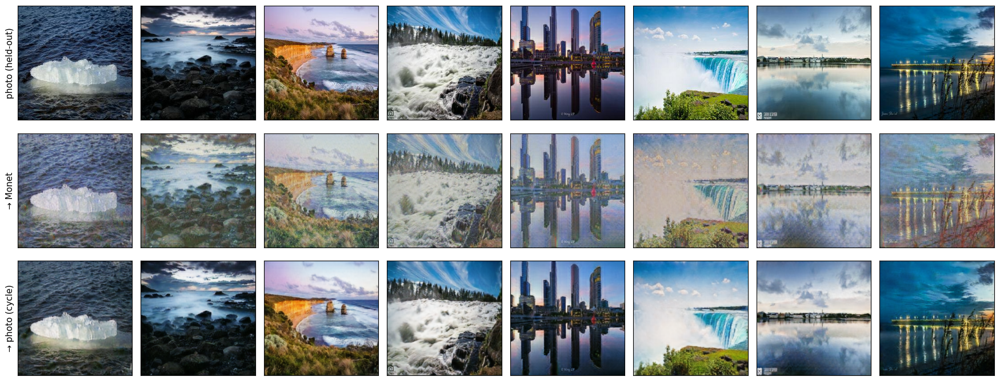

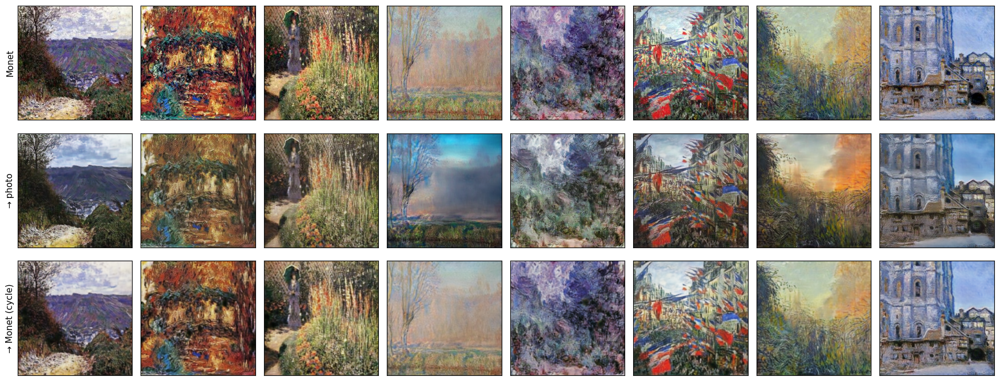

In [34]:
def triptych(inp, out, rec, labels, path, n=8, seed=SEED):
    idx = np.random.RandomState(seed).choice(len(inp), n, replace=False)
    fig, axes = plt.subplots(3, n, figsize=(2.2 * n, 7))
    for j, i in enumerate(idx):
        for r, src in enumerate((inp, out, rec)):
            axes[r, j].imshow(src[i].permute(1, 2, 0).numpy()); axes[r, j].set_xticks([]); axes[r, j].set_yticks([])
    for r, lab in enumerate(labels): axes[r, 0].set_ylabel(lab, fontsize=11)
    plt.tight_layout(); fig.savefig(path, dpi=110); plt.show()

triptych(photo_eval, fake_monet, rec_photo, ["photo (held-out)", "→ Monet", "→ photo (cycle)"], FIG_DIR / "qual_photo2monet.png")
triptych(monet_u8, fake_photo, rec_monet, ["Monet", "→ photo", "→ Monet (cycle)"], FIG_DIR / "qual_monet2photo.png")

## 8. Verifying the cycle-consistency implementation

Checks that the constraint is wired correctly, not just that a number came out:

1. Generators map [-1,1] → [-1,1] at the same resolution (tanh output, shapes match).
2. The cycle loss for the photo cycle produces non-zero gradients in **both** generators (F∘G is actually composed), and the generator not in the cycle path of an identity loss gets none.
3. Reconstruction error is far below the "unrelated image" baseline and below the error between input and its translation — i.e. the round trip really returns to the input.
4. Cycle loss went down over training.

In [35]:
checks = {}
x = to_float(photo_eval[:2].to(DEVICE))
with torch.no_grad():
    y = G_P2M(x)
checks["shape_preserved"] = tuple(y.shape) == tuple(x.shape)
checks["output_in_[-1,1]"] = bool(y.min() >= -1 and y.max() <= 1)

# gradient routing test (fp32, raw generators)
for p in G_params: p.grad = None
l1(G_M2P(G_P2M(x)), x).backward()
gP2M = sum(p.grad.abs().sum().item() for p in G_P2M.parameters() if p.grad is not None)
gM2P = sum(p.grad.abs().sum().item() for p in G_M2P.parameters() if p.grad is not None)
checks["cycle_grad_reaches_G_P2M"] = gP2M > 0
checks["cycle_grad_reaches_G_M2P"] = gM2P > 0
for p in G_params: p.grad = None
xm = to_float(monet_u8[:2].to(DEVICE))
l1(G_P2M(xm), xm).backward()     # identity loss for the Monet generator only
checks["identity_grad_isolated"] = all(p.grad is None or p.grad.abs().sum() == 0 for p in G_M2P.parameters())
for p in G_params: p.grad = None

checks["recL1_photo < 0.5*unrelated"] = M["cycle_L1_photo"] < 0.5 * M["cycle_L1_unrelated_baseline"]
checks["recL1_monet < 0.5*unrelated"] = M["cycle_L1_monet"] < 0.5 * M["cycle_L1_unrelated_baseline"]
checks["recL1_photo < L1(input, translation)"] = M["cycle_L1_photo"] < float(l1_px(photo_eval, fake_monet).mean())
checks["cycle_loss_decreased"] = stab["cyc_last_quarter"] < stab["cyc_first_quarter"]

for k, v in checks.items(): log(f"check {k:40s} {'PASS' if v else 'FAIL'}")
log(f"cycle L1 photo {M['cycle_L1_photo']:.4f} | monet {M['cycle_L1_monet']:.4f} | unrelated baseline {M['cycle_L1_unrelated_baseline']:.4f}")

[2026-10-01 03:19:51] check shape_preserved                          PASS
[2026-10-01 03:19:51] check output_in_[-1,1]                         PASS
[2026-10-01 03:19:51] check cycle_grad_reaches_G_P2M                 PASS
[2026-10-01 03:19:51] check cycle_grad_reaches_G_M2P                 PASS
[2026-10-01 03:19:51] check identity_grad_isolated                   PASS
[2026-10-01 03:19:51] check recL1_photo < 0.5*unrelated              PASS
[2026-10-01 03:19:51] check recL1_monet < 0.5*unrelated              PASS
[2026-10-01 03:19:51] check recL1_photo < L1(input, translation)     PASS
[2026-10-01 03:19:51] check cycle_loss_decreased                     PASS
[2026-10-01 03:19:51] cycle L1 photo 0.0934 | monet 0.0678 | unrelated baseline 0.5742


## 9. Error analysis

The worst translations ranked by two automatic signals: lowest content cosine (structure lost) and highest reconstruction LPIPS (cycle failed — usually means the generator hid information or hallucinated). These are the cases to discuss in the shortcomings section.

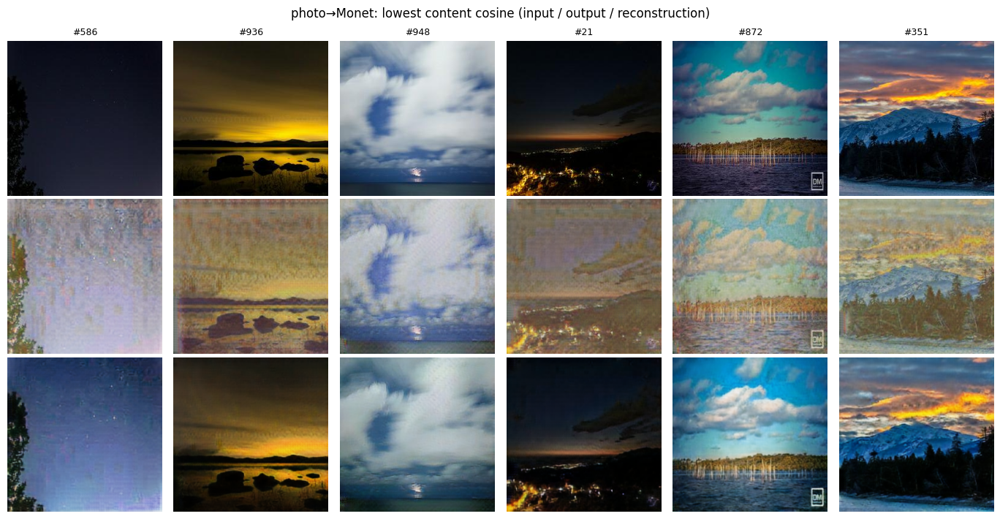

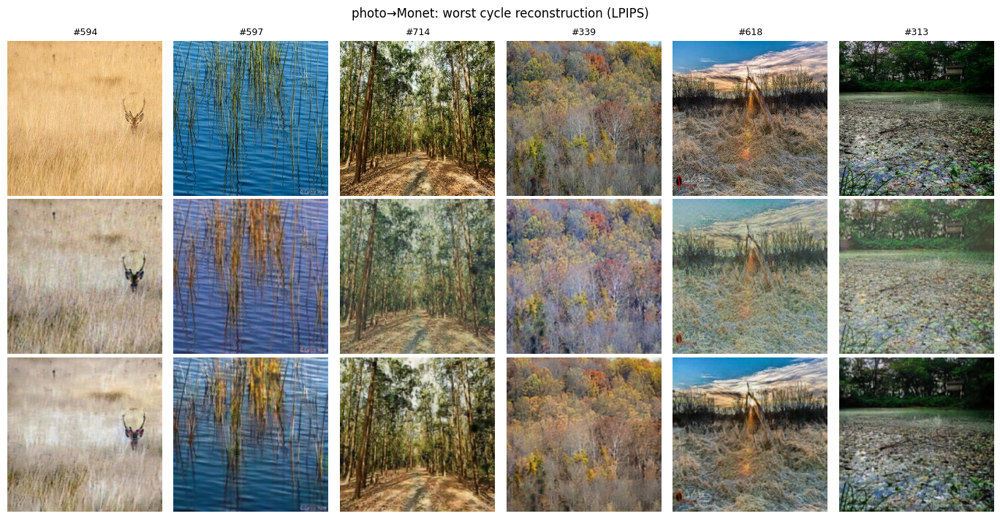

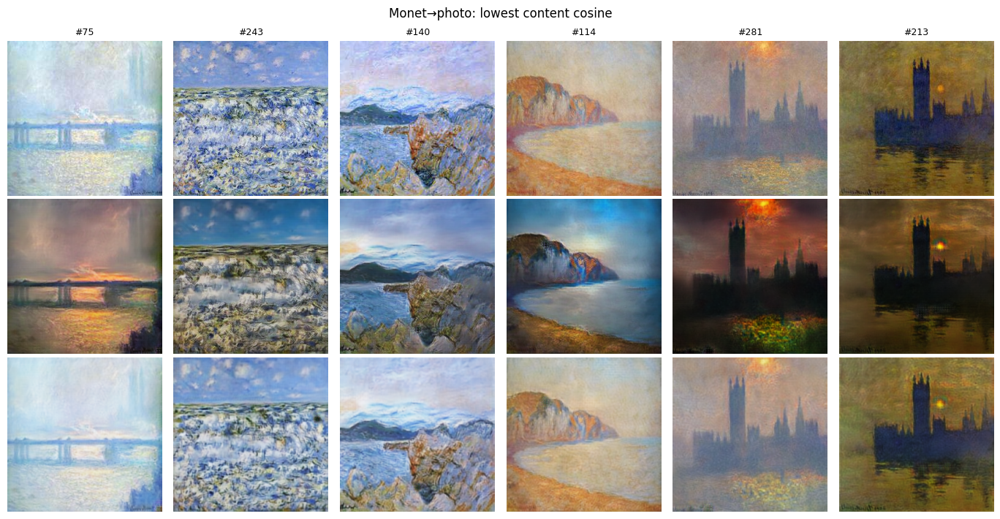

[2026-10-01 03:20:05] corr(content cos, brightness) = +0.126 | corr(content cos, colourfulness) = -0.039 | corr(rec LPIPS, brightness) = -0.084


In [36]:
def worst_grid(order, inp, out, rec, title, path, n=6):
    fig, axes = plt.subplots(3, n, figsize=(2.3 * n, 7.2))
    for j, i in enumerate(order[:n]):
        for r, src in enumerate((inp, out, rec)):
            axes[r, j].imshow(src[i].permute(1, 2, 0).numpy()); axes[r, j].axis("off")
        axes[0, j].set_title(f"#{i}", fontsize=9)
    fig.suptitle(title); plt.tight_layout(); fig.savefig(path, dpi=110); plt.show()

worst_grid(np.argsort(cos_p2m), photo_eval, fake_monet, rec_photo,
           "photo→Monet: lowest content cosine (input / output / reconstruction)", FIG_DIR / "worst_content_p2m.png")
worst_grid(np.argsort(-lp_recP), photo_eval, fake_monet, rec_photo,
           "photo→Monet: worst cycle reconstruction (LPIPS)", FIG_DIR / "worst_cycle_p2m.png")
worst_grid(np.argsort(cos_m2p), monet_u8, fake_photo, rec_monet,
           "Monet→photo: lowest content cosine", FIG_DIR / "worst_content_m2p.png")

# Does failure correlate with input properties? (brightness / colourfulness of the input photo)
bright = photo_eval.float().mean(dim=(1, 2, 3)).numpy()
colorf = photo_eval.float().std(dim=1).mean(dim=(1, 2)).numpy()
log(f"corr(content cos, brightness) = {np.corrcoef(cos_p2m, bright)[0,1]:+.3f} | "
    f"corr(content cos, colourfulness) = {np.corrcoef(cos_p2m, colorf)[0,1]:+.3f} | "
    f"corr(rec LPIPS, brightness) = {np.corrcoef(lp_recP, bright)[0,1]:+.3f}")

## 10. Efficiency

In [37]:
@torch.no_grad()
def bench_inference(G, bs=16, warmup=10, iters=50, repeats=5):
    x = torch.randn(bs, 3, CFG["img_size"], CFG["img_size"], device=DEVICE)
    if CFG["channels_last"]: x = x.contiguous(memory_format=torch.channels_last)
    G.eval(); rates = []
    for _ in range(warmup):
        with torch.autocast(**AMP): G(x)
    for _ in range(repeats):
        if DEVICE.type == "cuda": torch.cuda.synchronize()
        t = time.perf_counter()
        for _ in range(iters):
            with torch.autocast(**AMP): G(x)
        if DEVICE.type == "cuda": torch.cuda.synchronize()
        rates.append(bs * iters / (time.perf_counter() - t))
    return float(np.median(rates)), float(np.std(rates))

if DEVICE.type == "cuda": torch.cuda.reset_peak_memory_stats()
INF_IPS, INF_IPS_STD = bench_inference(EMA_P2M, iters=5 if QUICK else 50)
PEAK_INF_MEM_GB = torch.cuda.max_memory_allocated() / 1024**3 if DEVICE.type == "cuda" else float("nan")

EFF = dict(
    params_G_each_M=PARAMS["G_P2M"] / 1e6, params_D_each_M=PARAMS["D_M"] / 1e6, params_total_M=PARAMS["total"] / 1e6,
    train_time_h=STATE["train_time"] / 3600, train_steps=STATE["step"],
    train_steps_per_s=STATE["step"] / STATE["train_time"],
    train_img_per_s_per_domain=STATE["step"] * CFG["batch_size"] / STATE["train_time"],
    infer_img_per_s_median=INF_IPS, infer_img_per_s_std=INF_IPS_STD,
    peak_mem_train_GB=PEAK_TRAIN_MEM_GB, peak_mem_infer_GB=PEAK_INF_MEM_GB,
    gpu=torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "cpu",
)
log("Efficiency:", json.dumps(EFF, default=str))
pd.Series(EFF).to_frame("value")

[2026-10-01 03:20:15] Efficiency: {"params_G_each_M": 11.378179, "params_D_each_M": 2.764737, "params_total_M": 28.285832, "train_time_h": 1.8345923272106384, "train_steps": 40000, "train_steps_per_s": 6.056446953533667, "train_img_per_s_per_domain": 24.22578781413467, "infer_img_per_s_median": 523.8009021091793, "infer_img_per_s_std": 4.663259012086198, "peak_mem_train_GB": 18.50528860092163, "peak_mem_infer_GB": 2.438640594482422, "gpu": "NVIDIA GeForce RTX 4090"}


,value
params_G_each_M,11.378179
params_D_each_M,2.764737
params_total_M,28.285832
train_time_h,1.834592
train_steps,40000
train_steps_per_s,6.056447
train_img_per_s_per_domain,24.225788
infer_img_per_s_median,523.800902
infer_img_per_s_std,4.663259
peak_mem_train_GB,18.505289


## 11. Kaggle submission

Translates **every** photo (7038, within the usual 7,000–10,000 range) with the best EMA photo→Monet generator and zips them as 256×256 JPEGs. These are produced by this notebook's own trained model only.

Check the competition's *Evaluation* / *Submission* section for the exact expected format; this follows the standard Monet competition format (`images.zip` of jpgs). If your class page asks for something different, only this cell needs to change.

In [38]:
SUB_ZIP = OUT_DIR / "images.zip"
t0 = time.time(); n_written = 0
with zipfile.ZipFile(SUB_ZIP, "w", zipfile.ZIP_DEFLATED) as zf:
    for i in range(0, len(photo_u8), 256):
        out = translate(EMA_P2M, photo_u8[i:i+256])
        for j, im in enumerate(out):
            buf = io.BytesIO()
            Image.fromarray(im.permute(1, 2, 0).numpy()).save(buf, format="JPEG", quality=95)
            zf.writestr(f"{photo_files[i+j].stem}.jpg", buf.getvalue())
            n_written += 1

with zipfile.ZipFile(SUB_ZIP) as zf:
    names = zf.namelist()
    probe = Image.open(io.BytesIO(zf.read(names[0])))
assert len(names) == len(photo_u8) == n_written and len(set(names)) == len(names)
log(f"Submission written: {SUB_ZIP} | {len(names)} images | size {probe.size} | "
    f"{SUB_ZIP.stat().st_size/1e6:.1f} MB | {time.time()-t0:.0f}s")

[2026-10-01 03:20:49] Submission written: /app/content/data266_cyclegan/images.zip | 7038 images | size (256, 256) | 199.3 MB | 30s


## 12. Blinded human audit (30 fixed samples, 2 raters)

Protocol:
* 30 samples fixed by `SEED`: 20 photo→Monet (held-out photos) + 10 Monet→photo.
* Each sample is a side-by-side image *input | output*, renamed to an anonymous ID and shuffled, so raters don't see file names, direction labels, or epoch. The mapping is in `_key.csv` — **raters must not open it**.
* Each rater fills **their own** copy of the sheet independently, without discussing.
* Scores (1–5 Likert):
  * **style** — how convincingly does the output look like the target domain (Monet painting / real photo)? 1 = not at all, 5 = indistinguishable.
  * **content** — are the scene layout and objects of the input preserved? 1 = unrecognisable, 5 = fully preserved.
  * **artifacts** — 1 = severe artifacts (checkerboard, blotches, colour bleeding), 5 = none visible.

In [48]:
AUDIT_DIR = OUT_DIR / "human_audit"; (AUDIT_DIR / "images").mkdir(parents=True, exist_ok=True)
ars = np.random.RandomState(SEED + 266)
a_p = ars.choice(len(photo_eval), 20, replace=False)
a_m = ars.choice(len(monet_u8), 10, replace=False)
items = [("photo2monet", int(i), photo_eval[i], fake_monet[i]) for i in a_p] + \
        [("monet2photo", int(i), monet_u8[i], fake_photo[i]) for i in a_m]
order = ars.permutation(len(items))
key_rows = []
for k, oi in enumerate(order):
    sid = f"S{k+1:02d}"
    direction, idx, inp, out = items[oi]
    pair = torch.cat([inp, torch.full((3, inp.shape[1], 8), 255, dtype=torch.uint8), out], dim=2)
    Image.fromarray(pair.permute(1, 2, 0).numpy()).save(AUDIT_DIR / "images" / f"{sid}.png")
    key_rows.append(dict(sample_id=sid, direction=direction, index=idx))
pd.DataFrame(key_rows).to_csv(AUDIT_DIR / "_key.csv", index=False)

for r in ("rater1", "rater2"):
    p = AUDIT_DIR / f"{r}.csv"
    if not p.exists():   # never overwrite a filled sheet
        pd.DataFrame(dict(sample_id=[f"S{k+1:02d}" for k in range(30)], style="", content="", artifacts="", notes="")).to_csv(p, index=False)

# One-page HTML viewer for raters
html = ["<html><body style='font-family:sans-serif'><h2>CycleGAN audit — rate each pair (input | output) 1-5 on style, content, artifacts</h2>"]
for k in range(30):
    html.append(f"<div style='margin:12px 0'><b>S{k+1:02d}</b><br><img src='images/S{k+1:02d}.png' width='520'></div>")
(AUDIT_DIR / "audit_sheet.html").write_text("\n".join(html + ["</body></html>"]))
log(f"Audit packet in {AUDIT_DIR}: images/, audit_sheet.html, rater1.csv, rater2.csv (+ _key.csv, hidden from raters)")

[2026-10-01 03:23:15] Audit packet in /app/content/data266_cyclegan/human_audit: images/, audit_sheet.html, rater1.csv, rater2.csv (+ _key.csv, hidden from raters)


**After both raters have filled `rater1.csv` and `rater2.csv`, run the next cell.** It skips cleanly if the sheets are still empty.

In [49]:
# Cohen's kappa without sklearn
def cohen_kappa(a, b, weights=None, labels=(1, 2, 3, 4, 5)):
    k = len(labels)
    pos = {lab: i for i, lab in enumerate(labels)}
    O = np.zeros((k, k))
    for x, y in zip(a, b):
        O[pos[x], pos[y]] += 1
    O /= O.sum()                                  # observed agreement matrix
    E = np.outer(O.sum(axis=1), O.sum(axis=0))    # expected by chance
    i, j = np.indices((k, k))
    if weights == "quadratic":
        W = (i - j) ** 2 / (k - 1) ** 2
    elif weights == "linear":
        W = np.abs(i - j) / (k - 1)
    else:
        W = (i != j).astype(float)
    denom = (W * E).sum()
    if denom == 0:          # both raters gave one constant score, kappa undefined
        return float("nan")
    return float(1 - (W * O).sum() / denom)


AUDIT = {}
CRIT = ["style", "content", "artifacts"]
r1 = pd.read_csv(AUDIT_DIR / "rater1.csv")
r2 = pd.read_csv(AUDIT_DIR / "rater2.csv")
filled = all(pd.to_numeric(r[c], errors="coerce").notna().all() for r in (r1, r2) for c in CRIT)

if not filled:
    log("audit: rating sheets not complete yet, fill rater1.csv / rater2.csv and re-run")
else:
    rows = []
    for c in CRIT:
        a = r1[c].astype(int).values
        b = r2[c].astype(int).values
        assert set(a) | set(b) <= {1, 2, 3, 4, 5}, f"{c}: scores must be 1-5"
        rows.append(dict(
            criterion=c,
            mean_r1=a.mean(), mean_r2=b.mean(), mean_both=(a.mean() + b.mean()) / 2,
            exact_agree=(a == b).mean(),
            within1_agree=(np.abs(a - b) <= 1).mean(),
            kappa=cohen_kappa(a, b),
            kappa_quadratic=cohen_kappa(a, b, weights="quadratic"),
        ))
    AUDIT_TABLE = pd.DataFrame(rows).round(3)

    key = pd.read_csv(AUDIT_DIR / "_key.csv")
    both = r1[CRIT].astype(int).add(r2[CRIT].astype(int)).div(2)
    both = both.assign(sample_id=r1.sample_id).merge(key, on="sample_id")
    BY_DIR = both.groupby("direction")[CRIT].mean().round(2)

    AUDIT = dict(overall_mean=float(both[CRIT].values.mean()),
                 table=AUDIT_TABLE.to_dict("records"),
                 by_direction=BY_DIR.to_dict())
    log("audit:\n" + AUDIT_TABLE.to_string(index=False) + "\nby direction:\n" + BY_DIR.to_string())
    display(AUDIT_TABLE)
    display(BY_DIR)

[2026-10-01 03:23:16] audit: rating sheets not complete yet, fill rater1.csv / rater2.csv and re-run


## 13. METRICS.md

Fill in the Kaggle numbers after submitting (they come from the leaderboard, not from this notebook), then run the cell.

In [50]:
KAGGLE_PUBLIC  = None   # e.g. 52.31  (from the leaderboard after submitting images.zip)
KAGGLE_PRIVATE = None   # available after the competition closes
KAGGLE_RANK    = None   # e.g. "7 / 41"

fmt = lambda v, p=4: "—" if v is None or (isinstance(v, float) and math.isnan(v)) else (f"{v:.{p}f}" if isinstance(v, float) else str(v))
L = [f"# METRICS — CycleGAN Monet ↔ Photo",
     f"", f"SID4={SID4:04d} | SEED={SEED} | SLICE={SLICE} | HP_ID={HP_ID} | CLS_A={CLS_A} | CLS_B={CLS_B}",
     f"Best EMA checkpoint: epoch {best['epoch']} of {CFG['epochs']} | GPU: {EFF['gpu']}", "",
     "## Distribution metrics (Inception-v3 pool3, 2048-d)", "",
     "| Metric | Photo → Monet | Monet → Photo |", "|---|---|---|",
     f"| FID ↓ | {fmt(M['FID_photo2monet'],2)} | {fmt(M['FID_monet2photo'],2)} |",
     f"| KID ×10³ ↓ (mean ± std) | {M['KID_photo2monet']*1e3:.2f} ± {M['KID_photo2monet_std']*1e3:.2f} | {M['KID_monet2photo']*1e3:.2f} ± {M['KID_monet2photo_std']*1e3:.2f} |",
     f"| Precision ↑ | {fmt(M['precision_photo2monet'])} | {fmt(M['precision_monet2photo'])} |",
     f"| Recall ↑ | {fmt(M['recall_photo2monet'])} | {fmt(M['recall_monet2photo'])} |",
     f"| Density ↑ | {fmt(M['density_photo2monet'])} | {fmt(M['density_monet2photo'])} |",
     f"| Coverage ↑ | {fmt(M['coverage_photo2monet'])} | {fmt(M['coverage_monet2photo'])} |",
     f"| Content cosine (input vs translation) ↑ | {fmt(M['content_cos_photo2monet'])} | {fmt(M['content_cos_monet2photo'])} |",
     f"| LPIPS input vs translation | {fmt(M['LPIPS_input_vs_translation_photo2monet'])} | {fmt(M['LPIPS_input_vs_translation_monet2photo'])} |",
     f"| Cycle reconstruction L1 ↓ | {fmt(M['cycle_L1_photo'])} (photo cycle) | {fmt(M['cycle_L1_monet'])} (Monet cycle) |",
     f"| LPIPS input vs reconstruction ↓ | {fmt(M['LPIPS_input_vs_reconstruction_photo'])} | {fmt(M['LPIPS_input_vs_reconstruction_monet'])} |",
     "",
     f"Reference points: FID photo-vs-photo split floor {M['FID_floor_photo_vs_photo']:.2f}; unrelated-pair L1 {M['cycle_L1_unrelated_baseline']:.4f}, "
     f"LPIPS {M['LPIPS_unrelated_baseline']:.4f}, content cosine {M['content_cos_unrelated_baseline']:.4f}. "
     f"MiFID (Kaggle-style, vs training Monets) {M['MiFID_photo2monet']:.2f}, memorisation distance {M['memorization_dist']:.4f}.",
     "", "## Training losses (mean over final 25% of steps)", "",
     "| Term | Value |", "|---|---|",
     f"| Discriminator total | {stab['D_last_quarter']:.4f} |",
     f"| Generator adversarial (both) | {stab['G_adv_last_quarter']:.4f} |",
     f"| Cycle-consistency L1 (both, unweighted) | {stab['cyc_last_quarter']:.4f} (first 25%: {stab['cyc_first_quarter']:.4f}) |",
     f"| Identity L1 (both, unweighted) | {stab['idt_last_quarter']:.4f} |",
     f"| λ_cyc / λ_id | {CFG['lambda_cyc']} / {CFG['lambda_id']} |",
     "", "Curves: `figures/training_curves.png`", "",
     "## Stability", "", "| Metric | G | D |", "|---|---|---|",
     f"| Grad-norm median | {stab['gnG_median']:.3f} | {stab['gnD_median']:.3f} |",
     f"| Grad-norm p99 | {stab['gnG_p99']:.3f} | {stab['gnD_p99']:.3f} |",
     f"| Grad-norm max | {stab['gnG_max']:.3f} | {stab['gnD_max']:.3f} |",
     f"| NaN/Inf steps | {STATE['nan_steps']} (of {STATE['step']}) | |",
     "", "## Human audit (30 samples, 2 raters, 1–5)", ""]
if AUDIT:
    L += ["| Criterion | Mean | Exact agree | ±1 agree | Cohen κ | Quadratic κ |", "|---|---|---|---|---|---|"]
    L += [f"| {r['criterion']} | {r['mean_both']:.2f} | {r['exact_agree']:.0%} | {r['within1_agree']:.0%} | {r['kappa']:.3f} | {r['kappa_quadratic']:.3f} |" for r in AUDIT["table"]]
    L += ["", f"Overall mean score: {AUDIT['overall_mean']:.2f}"]
else:
    L += ["_Pending — run the audit scoring cell after both raters finish._"]
L += ["", "## Efficiency", "", "| Metric | Value |", "|---|---|",
      f"| Params per generator / discriminator | {EFF['params_G_each_M']:.2f}M / {EFF['params_D_each_M']:.2f}M |",
      f"| Params total | {EFF['params_total_M']:.2f}M |",
      f"| Training time | {EFF['train_time_h']:.2f} h ({EFF['train_steps']} steps, batch {CFG['batch_size']}) |",
      f"| Training throughput | {EFF['train_img_per_s_per_domain']:.1f} img/s per domain |",
      f"| Inference throughput (bs 16, median of 5) | {EFF['infer_img_per_s_median']:.1f} ± {EFF['infer_img_per_s_std']:.1f} img/s |",
      f"| Peak GPU memory train / inference | {fmt(EFF['peak_mem_train_GB'],2)} GB / {fmt(EFF['peak_mem_infer_GB'],2)} GB |",
      "", "## Kaggle", "", "| Public | Private | Rank |", "|---|---|---|",
      f"| {fmt(KAGGLE_PUBLIC)} | {fmt(KAGGLE_PRIVATE)} | {fmt(KAGGLE_RANK)} |",
      "", "Submission generated by `images.zip` cell from this notebook's best EMA photo→Monet generator.",
      "", "## Reproduce", "", "Run `cyclegan_monet.ipynb` top to bottom with `QUICK=False` (config in `config.json`)."]
(OUT_DIR / "METRICS.md").write_text("\n".join(L))
json.dump(dict(metrics=M, stability=stab, efficiency=EFF, checks={k: bool(v) for k, v in checks.items()}, audit=AUDIT),
          open(OUT_DIR / "metrics.json", "w"), indent=2, default=float)
log(f"Wrote {OUT_DIR/'METRICS.md'} and metrics.json")
print("\n".join(L))

[2026-10-01 03:23:19] Wrote /app/content/data266_cyclegan/METRICS.md and metrics.json
# METRICS — CycleGAN Monet ↔ Photo

SID4=9002 | SEED=9002 | SLICE=2 | HP_ID=2 | CLS_A=2 | CLS_B=3
Best EMA checkpoint: epoch 45 of 50 | GPU: NVIDIA GeForce RTX 4090

## Distribution metrics (Inception-v3 pool3, 2048-d)

| Metric | Photo → Monet | Monet → Photo |
|---|---|---|
| FID ↓ | 94.67 | 86.15 |
| KID ×10³ ↓ (mean ± std) | 19.48 ± 2.06 | 18.55 ± 2.08 |
| Precision ↑ | 0.4320 | 0.6833 |
| Recall ↑ | 0.6567 | 0.4500 |
| Density ↑ | 0.3158 | 0.7300 |
| Coverage ↑ | 0.7900 | 0.4540 |
| Content cosine (input vs translation) ↑ | 0.7655 | 0.8164 |
| LPIPS input vs translation | 0.3718 | 0.3016 |
| Cycle reconstruction L1 ↓ | 0.0934 (photo cycle) | 0.0678 (Monet cycle) |
| LPIPS input vs reconstruction ↓ | 0.2077 | 0.2735 |

Reference points: FID photo-vs-photo split floor 57.32; unrelated-pair L1 0.5742, LPIPS 0.8114, content cosine 0.5689. MiFID (Kaggle-style, vs training Monets) 94.67, memorisation d

## 14. Copy deliverables into the repo folder

Copies `RUN_LOG.txt`, `METRICS.md`, `metrics.json`, `config.json`, the training history CSVs, `figures/` and the audit sheets from `OUT_DIR` into the folder this notebook lives in (your `data266-<SID4>` repo). Checkpoints and `images.zip` are too large for git; they stay in `OUT_DIR` (link them in the README).

In [51]:
import shutil
REPO_DIR = Path(os.getcwd())
if REPO_DIR.resolve() != OUT_DIR.resolve():
    for name in ["RUN_LOG.txt", "METRICS.md", "metrics.json", "config.json", "train_history.csv", "eval_history.csv"]:
        if (OUT_DIR / name).exists():
            shutil.copy2(OUT_DIR / name, REPO_DIR / name)
    for d in ["figures", "samples"]:
        if (OUT_DIR / d).exists():
            shutil.copytree(OUT_DIR / d, REPO_DIR / d, dirs_exist_ok=True)
    (REPO_DIR / "human_audit").mkdir(exist_ok=True)
    for f in (OUT_DIR / "human_audit").glob("*.*"):
        shutil.copy2(f, REPO_DIR / "human_audit" / f.name)
    shutil.copytree(OUT_DIR / "human_audit" / "images", REPO_DIR / "human_audit" / "images", dirs_exist_ok=True)
    log(f"Deliverables copied to {REPO_DIR}")
log(f"Checkpoint (best EMA): {CKPT_DIR / 'best_ema.pt'} | submission: {OUT_DIR / 'images.zip'}")

[2026-10-01 03:23:36] Deliverables copied to /app
[2026-10-01 03:23:36] Checkpoint (best EMA): /app/content/data266_cyclegan/checkpoints/best_ema.pt | submission: /app/content/data266_cyclegan/images.zip


## 15. Analysis & discussion

*Write this after the run, using the numbers above. Prompts for each part of 3.1(5) and 3.2:*

**Visual quality.** Look at `qual_photo2monet.png` / `qual_monet2photo.png`. Which Monet traits come through (brush texture, palette, softened edges) and which don't? Monet→photo is the harder direction (adding detail the painting never had) — does it show?

**Cycle-consistency.** Report the check table from Section 8. Compare cycle L1 with the unrelated-pair baseline. Look at the reconstructions: CycleGAN is known to "steganographically" hide input detail in near-invisible high-frequency patterns of the output (Chu et al., 2017), so near-perfect reconstruction from a heavily stylised output is not purely good news.

**Training stability / convergence.** From `training_curves.png`: do D outputs stay away from 0/1 (no D collapse)? Gradient norms bounded, NaN count? Does the cycle loss plateau, and does FID keep improving into the LR-decay phase? Where was the best checkpoint?

**Metric caveats / shortcomings.**
* Monet-side FID uses only 300 reference images, so it has a large positive bias and high variance; KID (unbiased) is the more reliable number at this sample size, and the photo-vs-photo split floor gives scale.
* The Monet references are also the training images, so photo→Monet FID partly rewards matching the training set; MiFID's memorisation distance checks we aren't copying.
* Inception features are trained on ImageNet photos; they are a weaker judge of painterly style than of photo realism.
* Content cosine uses the same Inception space; it measures semantic, not pixel-exact, preservation.
* Run-to-run non-determinism (cudnn autotuning, atomic adds in some backward kernels) means exact numbers differ slightly between runs with the same seed.

**Human audit.** Report means and κ per criterion. Interpret κ on Landis & Koch's scale; low κ with high ±1 agreement usually means raters agree on order but use the scale differently.

**Kaggle.** Public/private score and rank.

In [53]:
# local estimate of the leaderboard metrics, computed on the actual images.zip
fid = fid_from_feats   # name used in this notebook

with zipfile.ZipFile(SUB_ZIP) as zf:
    names = sorted(zf.namelist())
    sub = np.stack([np.asarray(Image.open(io.BytesIO(zf.read(n))).convert("RGB")) for n in names])
sub_u8 = torch.from_numpy(sub).permute(0, 3, 1, 2).contiguous()
del sub

F_sub = inception_feats(sub_u8)      # generated (what Kaggle will score)
F_real = REAL_MONET_FEATS            # real target domain = 300 Monets
log(f"submission feats {F_sub.shape} vs real monet {F_real.shape}")

def unit(x):
    return x / np.linalg.norm(x, axis=1, keepdims=True)

LB = {"FID_all_generated": fid(F_sub, F_real)}

# MiFID as the page defines it: subsample to equal set sizes, average cosine distance.
# Subsampling is random, so repeat it and report mean +- std.
rs = np.random.RandomState(SEED)
n = min(len(F_sub), len(F_real))
paired, nearest, fid_eq = [], [], []
for _ in range(20):
    g = unit(F_sub[rs.choice(len(F_sub), n, replace=False)])
    r = unit(F_real[rs.choice(len(F_real), n, replace=False)])
    paired.append(float((1 - (g * r).sum(1)).mean()))       # d_i between i-th generated and i-th real
    nearest.append(float((1 - g @ r.T).min(1).mean()))      # nearest-real variant
    fid_eq.append(fid(F_sub[rs.choice(len(F_sub), n, replace=False)], F_real))

LB["MiFID_paired_mean"], LB["MiFID_paired_std"] = np.mean(paired), np.std(paired)
LB["MiFID_nearest_mean"], LB["MiFID_nearest_std"] = np.mean(nearest), np.std(nearest)
LB["FID_equal_size_mean"], LB["FID_equal_size_std"] = np.mean(fid_eq), np.std(fid_eq)

log("leaderboard-style estimate:\n" + json.dumps({k: round(float(v), 4) for k, v in LB.items()}, indent=1))
M.update({f"LB_est_{k}": float(v) for k, v in LB.items()})
pd.Series(LB).round(4).to_frame("local estimate")

[2026-10-01 03:26:31] submission feats (7038, 2048) vs real monet (300, 2048)
[2026-10-01 03:27:48] leaderboard-style estimate:
{
 "FID_all_generated": 82.5695,
 "MiFID_paired_mean": 0.4074,
 "MiFID_paired_std": 0.0031,
 "MiFID_nearest_mean": 0.2498,
 "MiFID_nearest_std": 0.003,
 "FID_equal_size_mean": 99.036,
 "FID_equal_size_std": 1.8975
}


,local estimate
FID_all_generated,82.5695
MiFID_paired_mean,0.4074
MiFID_paired_std,0.0031
MiFID_nearest_mean,0.2498
MiFID_nearest_std,0.0030
FID_equal_size_mean,99.0360
FID_equal_size_std,1.8975


In [54]:
# final leaderboard score as defined on the Evaluation page: mean of FID and MiFID
score_all = (LB["FID_all_generated"] + LB["MiFID_paired_mean"]) / 2
score_eq  = (LB["FID_equal_size_mean"] + LB["MiFID_paired_mean"]) / 2

LB["score_est_all_generated"] = score_all
LB["score_est_equal_size"] = score_eq
M["LB_est_score_all_generated"] = float(score_all)
M["LB_est_score_equal_size"] = float(score_eq)

log(f"FID (all 7038 vs 300 Monet)  {LB['FID_all_generated']:.2f}")
log(f"FID (equal size, 20 draws)   {LB['FID_equal_size_mean']:.2f} +- {LB['FID_equal_size_std']:.2f}")
log(f"MiFID (paired cosine dist)   {LB['MiFID_paired_mean']:.4f} +- {LB['MiFID_paired_std']:.4f}")
log(f"estimated final score        {score_all:.2f}  (if Kaggle uses all generated images)")
log(f"                             {score_eq:.2f}  (if Kaggle subsamples FID to equal size too)")

[2026-10-01 03:28:45] FID (all 7038 vs 300 Monet)  82.57
[2026-10-01 03:28:45] FID (equal size, 20 draws)   99.04 +- 1.90
[2026-10-01 03:28:45] MiFID (paired cosine dist)   0.4074 +- 0.0031
[2026-10-01 03:28:45] estimated final score        41.49  (if Kaggle uses all generated images)
[2026-10-01 03:28:45]                              49.72  (if Kaggle subsamples FID to equal size too)


In [57]:
# one-row submission CSV, Kaggle expects the id column to be named "ID"
ROW = {
    "ID": 1,
    "FID": LB["FID_all_generated"],
    "MiFID": LB["MiFID_paired_mean"],
}

SUB_CSV = OUT_DIR / "submission.csv"
pd.DataFrame([ROW]).to_csv(SUB_CSV, index=False)
log(f"wrote {SUB_CSV}")
print(open(SUB_CSV).read())

[2026-10-01 03:40:54] wrote /app/content/data266_cyclegan/submission.csv
ID,FID,MiFID
1,82.5694566339053,0.40739294504832646

